In [68]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

from scipy.stats import expon, norm, pearsonr, shapiro, uniform
from sklearn.metrics import root_mean_squared_error
from statsmodels.stats.outliers_influence import variance_inflation_factor

------

# Linear regression assumptions

The purpose of this notebook is to outline the assumptions of the linear regression model and demonstrate why they are important. Note that the form of the 



---------

## 1. Linearity

Kind of obvious. We assume that the relationship between our predictors and our response is linear. If it is not then a simple linear regression model will not provide a very good fit to the data - see below an example of this.

This relates to discussions about estimating *f*, the true relationship between the predictors and the response, in chapter 2 of An Introduction to Statistical Learning. The linear regression model is a parametric method, meaning that it makes certain assumptions about the form of *f*, i.e. that it is linear. If *f* is not linear (or close to linear), then we can still fit a linear regression model but it will be a poor representation of *f* and any results will not be useful.

Below is an example of trying to fit a linear regression model to a dataset where the true relationship between the variables and the response is,

$ Y = (X - 0.5)^{2} + \epsilon $,

which is highly non-linear. Trying to fit a best-fit straight line to an equation of this form is clearly not going to go well, which is what we seee below.

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                 0.0001305
Date:                Sat, 24 Jan 2026   Prob (F-statistic):              0.991
Time:                        19:53:17   Log-Likelihood:                 110.31
No. Observations:                 100   AIC:                            -216.6
Df Residuals:                      98   BIC:                            -211.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0848      0.016      5.268      0.0

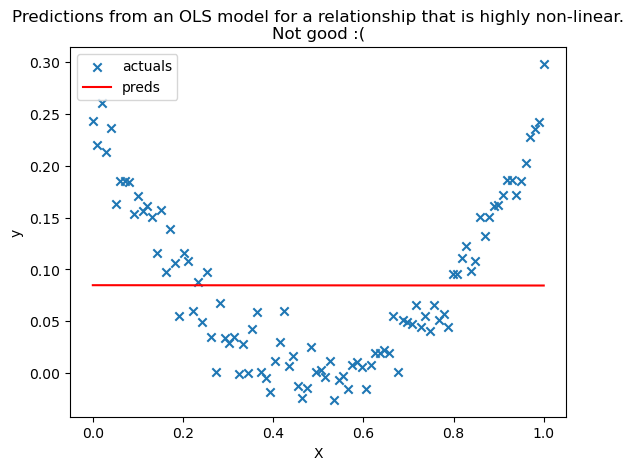

In [3]:
n_rows = 100

X = np.linspace(0, 1, n_rows)
Y = (X - 0.5)**2 + np.random.normal(0, 0.02, n_rows)

X_ = sm.add_constant(X)
model = sm.OLS(Y, X_).fit()
preds = model.predict(X_)

print(model.summary())

fig, ax = plt.subplots()
ax.scatter(X, Y, marker="x", label="actuals")
ax.plot(X, preds, color="r", label="preds")

ax.set_xlabel("X")
ax.set_ylabel("y")
ax.set_title("Predictions from an OLS model for a relationship that is highly non-linear.\nNot good :(")
ax.legend();

### 1.1 Transforming X to get a better fit

However, all is not lost. An important point is that we assume linearity between our response and our **predictors**. The variable *X* may not have a linear relationship but there is nothing to prevent us from transforming it into a form which *does* have a linear relationship.

Below we transform *X* with the equation $ X_{trans} = (X - 0.5)^{2} $ and then fit to this new variable - now we get a much better fit. Rather than the model coefficient relating directly to *X*, it relates to $ (X - 0.5)^{2} $. That is, we are choosing model coefficients, $\beta_{i}$, to minimise the sum of the residuals, where the assumed relationship is of the form,

$ f(X) = \beta_{0} + \beta_{1}*(X - 0.5)^{2} $.

We should interpret the estimated coefficient in this context.

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.941
Model:                            OLS   Adj. R-squared:                  0.940
Method:                 Least Squares   F-statistic:                     1551.
Date:                Sat, 24 Jan 2026   Prob (F-statistic):           6.90e-62
Time:                        19:53:17   Log-Likelihood:                 251.47
No. Observations:                 100   AIC:                            -498.9
Df Residuals:                      98   BIC:                            -493.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0024      0.003     -0.815      0.4

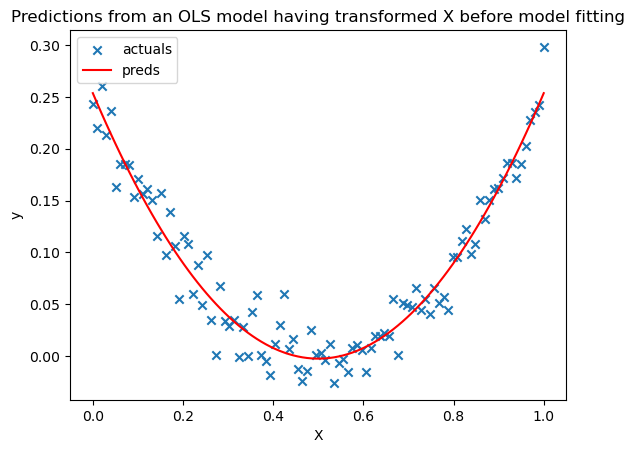

In [4]:
# now transform X so a linear regression model can be more useful
X_clean = (X - 0.5)**2

X_ = sm.add_constant(X_clean)
model = sm.OLS(Y, X_).fit()
preds = model.predict(X_)

print(model.summary())

fig, ax = plt.subplots()
ax.scatter(X, Y, marker="x", label="actuals")
ax.plot(X, preds, color="r", label="preds")

ax.set_xlabel("X")
ax.set_ylabel("y")
ax.set_title("Predictions from an OLS model having transformed X before model fitting")
ax.legend();

### 1.2 A more general approach to transforming variables

In this scenario we know the exact form of *f*, so it is trivial to transform *X* into a useful form. In the real world we do not always know what the true form of $f$ is so we cannot do this. The first step is visual: plotting $Y$ against each predictor (scatterplots, smooth trend lines) often reveals curvature, asymmetry, or diminishing returns that suggest candidate transformations. For example, multiplicative or diminishing-effect behaviour points toward logs; U-shapes point toward polynomials; sharp early increases that level off suggest square roots. Residual plots after an initial linear fit are equally valuable: systematic patterns in the residuals are a strong signal that the model needs additional structure.

From there, we typically iterate between modelling and checking. One route is to try a family of common transformations—polynomials of degree 2 or 3, logs, square roots—and evaluate improvements in fit and residual behaviour. Another route is to replace manual guessing with flexible tools such as splines or generalized additive models (GAMs), which allow the data to reveal its own shape. These methods can show you the smooth functional form, which you can then approximate using simpler engineered features if interpretability is important. In short, when the form of *f* is unknown, we discover it through visualisation, diagnostic checking, and the use of flexible models that expose the underlying structure before committing to a specific transformation.

Below is an example of how we can use the `PolynomialFeatures` class from sklearn. By fitting it to our data with `degree = 2`, we get an output array with three columns which contain a constant, the value of $X$, and of $X^{2}$. We then fit our linear regression model to this array and get some outputs. Because $ (X-0.5)^{2} = X^{2} - X + 0.25 $, this is exactly the same as fitting to $ (X-0.5)^{2} $ as in section 1.1, except that we get three coefficients rather than 1. We could also choose to increase the `degree` parameter to higher values, i.e. getting a polynomial of higher and higher powers, but in this case there is no need. This is an example of the trade-off between bias and variance. By increasing the complexity of the model through assuming a polynomial with higher powers, we will reduce the bias of the model but increase its variance. In this case a model with `degree > 2` will be fitting to the noise in the data, rather than capturing anything new about the true form of *f*. When we don't know the true form of *f*, we should look at how the performance of the model changes with increasing complexity; when the performance does not change with increased complexity, we should consider whether we are simply fitting to noise.

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.941
Model:                            OLS   Adj. R-squared:                  0.939
Method:                 Least Squares   F-statistic:                     767.8
Date:                Sat, 24 Jan 2026   Prob (F-statistic):           3.41e-60
Time:                        19:53:17   Log-Likelihood:                 251.47
No. Observations:                 100   AIC:                            -496.9
Df Residuals:                      97   BIC:                            -489.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2538      0.006     43.427      0.0

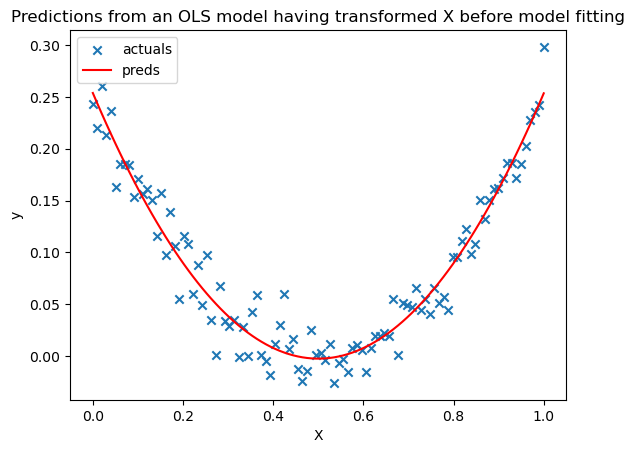

In [5]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(2)
X_clean = poly.fit_transform(X.reshape(-1, 1))

model = sm.OLS(Y, X_clean).fit()
preds = model.predict(X_clean)

print(model.summary())

fig, ax = plt.subplots()
ax.scatter(X, Y, marker="x", label="actuals")
ax.plot(X, preds, color="r", label="preds")

ax.set_xlabel("X")
ax.set_ylabel("y")
ax.set_title("Predictions from an OLS model having transformed X before model fitting")
ax.legend();

-----

## 2. Errors are independent of the predictors (exogeneity)

In a mathematical form, exogeneity is the following property,

$ \mathop{{}\mathbb{E}}[\epsilon | X] = 0 $

Here $ \epsilon $ is defined as the true error rather than the residuals, i.e. it is the term in the equation for the assumed form of the relationship between *X* and *Y*, $ Y = \beta_{0} + \beta_{1} * X + \epsilon $. $ \epsilon $ captures everything affecting *Y* that is not in the model, e.g. random noise, omitted variables, unmeasured influences, luck etc. The above equation therefore says that there is no relationship between the predictors and the errors, which means that once we know the predictors, there is no remaining systematic pattern in the error terms and the remaining error is just random noise. 

The reason that this matters is because of the way that the coefficients are calculated:

$ \hat{\beta_{1}} = \frac{Cov(X, Y)}{Var(X)}$

where $Y = \beta_{1}X + \epsilon$, so

$ Cov(X, Y) = \beta_{1}Var(X) + Cov(X, \epsilon) $

and

$ \hat{\beta_{1}} = \beta_{1} + \frac{Cov(X, \epsilon)}{Var(X)} $

Therefore, for $ \hat{\beta_{1}} = \beta_{1} $, we need $Cov(X, \epsilon) = 0$. If the true errors (not residuals) are correlated with the predictors, then we will get a biased coefficient. This means that the estimated coefficient is not equal to the true coefficient, even if we train many models over many random samples and take the average value of $\hat{\beta_{1}}$. Note that this not mean that our model is automatically a bad predictor, but it means that we cannot reliably use it for inference (this is the case with most of the linear regression assumptions).

An example of how the exogeneity assumption is violated is when there are two correlated predictors that each influence the response independently, but one of the predictors is omitted from the estimator. For example, both $LevelOfEducation$ and $Ability$ are predictors of $Salary$, and are also correlated with each other. If we only include one these predictors then we may assume a relationship of the form $Wage = \beta_{0} + \beta_{1}*LevelOfEducation + \epsilon$ where now the relationship between $Ability$ and $Salary$ is included in the error term. When we fit this model, we will attribute the effect of $Ability$ to the $LevelOfEducation$ variable, which means that the estimated coefficient for this variable will not be equal to the true value even when averaged over many samples, i.e. it is biased: $\hat{\beta}_{1} \neq \beta_{1}$. This is not necessarily an issue if we simply want our model to be a good predictor, however it can have implications for inference because we will not know the true relationship between our predictor and the target.

Another example is the relationship between the people being at the beach, ice cream sales and shark attacks. Fitting a model between IceCreamSales and SharkAttacks in the absence of PeopleBeingAtTheBeach would result in a non-zero coefficient. This illustrates the fact that we do not even need for the included variables to have a causal relationship with the target - only for the error term to contain information other than random noise.

We will reproduce an example such as the Salary example below. We create two correlated variables that both influence the response, $Y = \beta_{0} + \beta_{1}*X_{1} + \beta_{2}*X_{2} + \epsilon$, and ensure that $X_{1}$ and $X_{2}$ are correlated. When regressing on both variables, we see that the estimate for $\beta_{1}$ is very close to the true value, but it changes significantly when excluding it. Note that this is often a significant problem for inference but the consequences may not be so siginificant for prediction. By reducing the true coefficient for X2 in the codeblock below, we can reduce the difference between the RMSE of the full model and the partial model, whilst still having a significant impact on the estimated coefficient for X1. Depending on the use case for the linear regression model, a lack of exogeneity may not be such a big issue.

In [6]:
np.random.seed(666)

# Sample size
n = 100

# True model: Y depends on X1 and X2, where X2 is correlated with X1
X1 = np.random.normal(0, 1, n)
X2 = 0.7 * X1 + np.random.normal(0, 0.5, n)

# True coefficients
beta0, beta1, beta2 = 2, 3, 5

# Response variable with noise
eps = np.random.normal(0, 1, n)
Y = beta0 + beta1 * X1 + beta2 * X2 + eps

# --- Model 1: Uses both X1 and X2
X_full = sm.add_constant(np.column_stack([X1, X2]))
model_full = sm.OLS(Y, X_full).fit()
preds_full = model_full.predict(X_full)
rmse_full = root_mean_squared_error(Y, preds_full)

# --- Model 2: regress only with X1
X_partial = sm.add_constant(X1)
model_partial = sm.OLS(Y, X_partial).fit()
preds_partial = model_partial.predict(X_partial)
rmse_partial = root_mean_squared_error(Y, preds_partial)

df_results = pd.DataFrame(
    {
        "X1_coef": [beta1, model_full.params[1], model_partial.params[1]],
        "p-value": [np.NaN, model_full.pvalues[1], model_partial.pvalues[1]],
        "RMSE": [np.NaN, rmse_full, rmse_partial]
    }, index=["TrueValue", "FullModel", "PartialModel"]
)

df_results


,X1_coef,p-value,RMSE
TrueValue,3.000000,NaN,NaN
FullModel,3.119946,4.487980e-31,1.014542
PartialModel,6.808402,1.007570e-41,2.774252


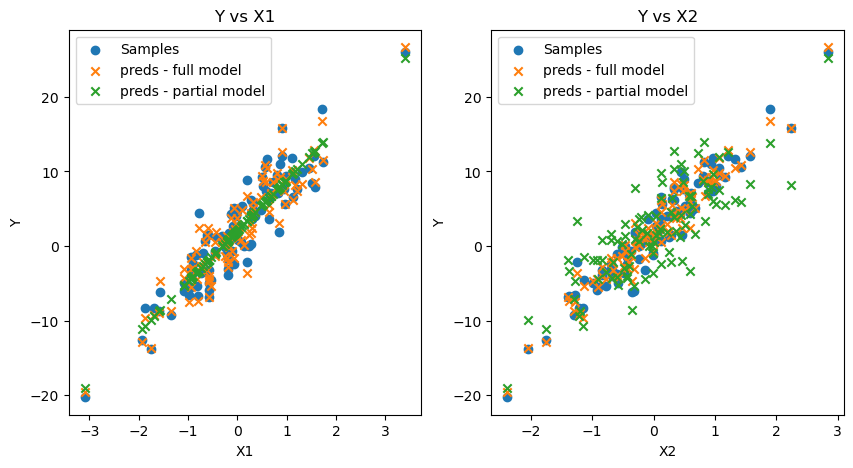

In [7]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 5))

ax1.scatter(X1, Y, label="Samples")
ax1.scatter(X1, preds_full, marker="x", label="preds - full model")
ax1.scatter(X1, preds_partial, marker="x", label="preds - partial model")

ax2.scatter(X2, Y, label="Samples")
ax2.scatter(X2, preds_full, marker="x", label="preds - full model")
ax2.scatter(X2, preds_partial, marker="x", label="preds - partial model")

for ax, x in zip((ax1, ax2), ("X1", "X2")):
    ax.set_xlabel(x)
    ax.set_ylabel("Y")
    ax.set_title(f"Y vs {x}")
    ax.legend()

--------

## 3. Constant variance across all error terms (homoscedasticity)

Meaning that the variance of the error term is constant across all values of $X$. Mathematically this is expressed as,

$ Var(\epsilon_{i} | X_{i}) = \sigma^{2} $ for all $i$

We can still fit to the data but the standard errors in the coefficients may be incorrect because the calculation of the variance in the coefficients assumes homoscedasticity and will therefore not return the correct answer. This leads to confidence intervals that are too narrow/wide and incorrect p-values. There are ways to handle scenarios where this assumption is violated. For example, we can use robust standard errors which are calculated in a way that does not assume homoscedasticity and will therefore return more realistic values. Note that heteroscedasticity does not lead to biased coefficients because we can still get the true value for our $\beta_{i}$ - this is only affected by the linearity and exogeneity conditions. 

An example of this assumption in action is if we are regressing income on education, where we would expect variance to increase as income increases. OLS will still find the best fit but we would end up over-trusting our predictions in the higher-variance (higher-income) regions.

Below we will generate data that has heteroscedastic errors and fit an OLS model to it. We will then use a hetereoscedasticity-robust covariance matrix to get a better estimate of the standard errors. This is a tool that can be used when the homoscedasticity assumption is violated. By using this, we get a higher standard error in our coefficients and a lower t-statistic. Though the result remains statistically significant, this example demonstrates how we might have a situation where we understate the standard errors and therefore overstate the t-statistic, potentially rejecting the null hypothesis when we should in fact be accepting it.

In [8]:
np.random.seed(666)

# Sample size
n = 500

# Predictor
X = np.random.normal(0, 5, n)

# Create heteroscedastic errors: variance grows with |X|
eps = np.random.normal(0, 1 + 2*abs(X), n)

# True model
beta0, beta1 = 2, 3
Y = beta0 + beta1*X + eps

# Fit OLS
X_design = sm.add_constant(X)
model_original = sm.OLS(Y, X_design).fit()

# Fit OLS with robust (HC3) standard errors
model_robust = model_original.get_robustcov_results(cov_type="HC3")


pd.DataFrame(
    [
        list(model.params) + [model.bse[-1], model.tvalues[-1]]
        for model in [model_original, model_robust]
    ], columns=[
        "Coef_X0",
        "Coef_X1",
        "StdError_X1",
        "t-statistic_X1",
    ], index=["OriginalModel", "RobustModel"]
)


,Coef_X0,Coef_X1,StdError_X1,t-statistic_X1
OriginalModel,1.908739,2.982971,0.088725,33.620595
RobustModel,1.908739,2.982971,0.148001,20.155130


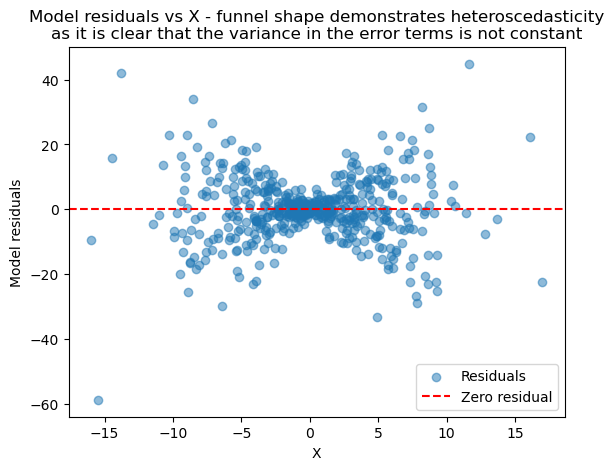

In [9]:
fig, ax = plt.subplots()

ax.scatter(X, model_original.resid, alpha=0.5, label="Residuals")
ax.axhline(0, color="red", linestyle="--", label="Zero residual")
ax.set_xlabel("X")
ax.set_ylabel("Model residuals")
ax.set_title("Model residuals vs X - funnel shape demonstrates heteroscedasticity\nas it is clear that the variance in the error terms is not constant");
ax.legend();

--------

## 4. Independence of the errors

This assumption states that the error terms are independent of one another,

$ Cov(\epsilon_{i}, \epsilon_{j}) = 0 $ for $ i \neq j $

The reason for this requirement relates to the calculation of the standard errors, which relies on this assumption. If the errors are correlated then the calculation of the standard errors will not be accurate, which also has consequences for the t-statistic and confidence intervals. So long as the error terms are not correlated with *X*, we can still get coefficient estimates that are good reflections of the actual values, meaning this is another example of an assumption that has consequences for inference but not prediction.

Below is an example where the error terms are equal to the sum of all errors up to that point, which means they are dependent. We show the standard errors when fitting the model normally as well as the errors when calculating robust standard errors. The difference in the standard errors and t-statistics is an illustration of the requirement for independence. 

### 4.1 Why does the intercept not equal the true value?

Note that the estimation of the intercept is not accurate. The reason for this is that the average error value is not equal to zero which drags the intercept away from its true value. We print the average error term value below to compare against the estimated coefficient and see that the two are close to each other, confirming this behaviour.

### 4.2 The Durbin-Watson statistic

One way of identifying auto-correlation among residuals is with the Durbin-Watson statistic, which is returned in the model summary below. Possible values are between 0 and 4 where values close to 2 imply no auto-correlation, and values close to 0 or 4 imply strong positive and negative auto-correlation, respectively - see [this link](https://www.statsmodels.org/dev/generated/statsmodels.stats.stattools.durbin_watson.html) for more detail.

In [10]:
np.random.seed(666)

# Sample size
n = 100

# Predictor
X = np.random.normal(0, 5, n)

# Create an array of errors where each error is the sum of all other errors up to that point
eps = np.random.normal(0, 1, n)
eps = np.cumsum(eps)

# True f
beta0, beta1 = 0, 3
Y = beta0 + beta1*X + eps

# Fit OLS
X_design = sm.add_constant(X)
model_original = sm.OLS(Y, X_design).fit()
print(model_original.summary())
print(f"Mean error value {np.mean(eps)}")

# Get robust standard errors. "HAC" gets the 
model_robust = model_original.get_robustcov_results(
    cov_type="HAC",
    # the maximum number of lags to use when checking whether the residuals are correlated. since
    # we are summing up all residuals, each residual is dependent on *all* previous residuals. For this reason
    # we choose a larger value here
    maxlags=10
)

pd.DataFrame(
    [[beta0, beta1, np.NaN, np.NaN]] + [
        list(model.params) + [model.bse[-1], model.tvalues[-1]]
        for model in [model_original, model_robust]
    ], columns=[
        "Coef_X0",
        "Coef_X1",
        "StdError_X1",
        "t-statistic_X1",
    ], index=["TrueValue", "OriginalModel", "RobustModel"]
)


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.968
Model:                            OLS   Adj. R-squared:                  0.968
Method:                 Least Squares   F-statistic:                     2986.
Date:                Sat, 24 Jan 2026   Prob (F-statistic):           3.28e-75
Time:                        19:53:17   Log-Likelihood:                -236.23
No. Observations:                 100   AIC:                             476.5
Df Residuals:                      98   BIC:                             481.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9553      0.259     11.390      0.0

,Coef_X0,Coef_X1,StdError_X1,t-statistic_X1
TrueValue,0.000000,3.000000,NaN,NaN
OriginalModel,2.955329,2.958682,0.054145,54.643977
RobustModel,2.955329,2.958682,0.064906,45.584047


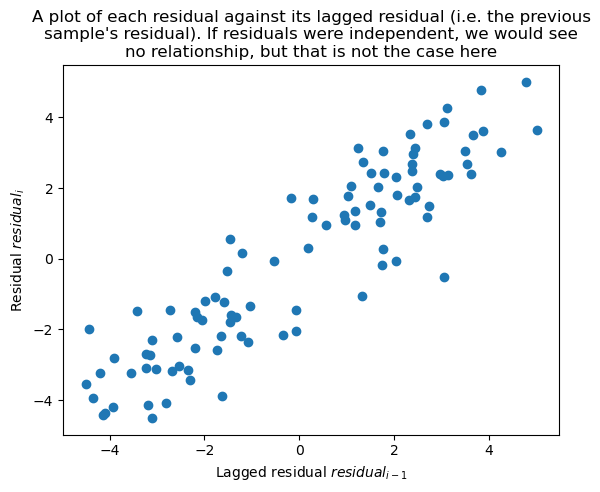

In [11]:
resid = model_original.resid
fig, ax = plt.subplots()

ax.scatter(resid[1:], resid[:-1])
ax.set_xlabel(r"Lagged residual $residual_{i-1}$")
ax.set_ylabel(r"Residual $residual_{i}$")
ax.set_title("A plot of each residual against its lagged residual (i.e. the previous\nsample's residual). If residuals were independent, we would see\nno relationship, but that is not the case here");

--------

## 5. Normality of the errors

This is another assumption that affects inference rather than prediction. It says that the error terms (not the residuals, but the underlying error terms in the form of *f*) should be normally-distributed. The reason for this is that if the errors are normally-distributed, then the OLS estimator is a linear combination of normal variables and the estimator is exactly normally distributed. 

### 5.1 How is the OLS estimator a linear combination of normal variables?

The "normal equations" represent the exact solution for the coefficients in the OLS estimator and are given by:

$ \hat\beta = (X^{\intercal}X)^{-1}X^{\intercal}y $

where $ y = X\beta + \epsilon $. Substituting for *y* gives

$ \hat\beta = (X^{\intercal}X)^{-1}X^{\intercal}(X\beta + \epsilon)  = \beta + (X^{\intercal}X)^{-1}X^{\intercal}\epsilon $

The only random component in this equation is $ \epsilon $ and all other components are simply constants. Therefore, each $ \hat\beta_{j} $ is simply a linear combination of the error terms $ \epsilon_{j} $

$ \hat\beta_{j} = \beta_{j} + \sum_{i=1}^{n}c_{ji}\epsilon_{i} $


Since a linear combination of independent normal variables is itself normally distributed, it follows that each $\hat\beta_{j}$ is exactly normally distributed, not just approximately. This is why, under normal errors, the t-statistic,

$ t_{j} = \frac{\hat\beta_{j} - \beta_{j}}{SE(\hat\beta_{j})} $

follows an exact Student's t-distribution, so the p-values and confidence intervals are exact, including in finite samples.

### 5.2 Application of the central limit theorem

In large samples the central limit theorem takes care of the normality assumption. Under the CLT, the coefficient estimate will still be approximately normally-distributed when the sample size is large, because of the way in which the coefficient is calculated. In the equation above,

$ \hat\beta = \beta + (X^{\intercal}X)^{-1}X^{\intercal}\epsilon $

the second term is a linear combination of many error terms. Even if the error terms are not normally-distributed, the CLT tells us that the (weighted) sum of many independent random variables will itself be approximately normally (the CLT actually typically refers to the mean but this is just the sum divided by some constant). This is why, in large samples, the OLS estimator is approximately normally-distributed even if the errors themselves are not exactly normal. Consequently, the t-statistics and confidence intervals based on $\hat\beta_{j}$ are still approximately valid.

Below we look at how the central limit theorem works. It says that the mean of any distribution is approximately normally-distributed, provided that the mean is being calculated with a sufficient number of observations. In the example below, we select a distribution (exponential as default but there is the option to choose uniform as well) and then sample repeatedly from it, calculating the mean for each sample. We then plot the distribution of the sample means compared with the normal distribution to see whether the two appear similar - when `n_rows_per_sample` is high we get a good fit (we also need `n_samples` to be high but that is only so the histogram has enough bars - the CLT says that the **number of observations** should be high, not the number of samples).

Next, we use two statistical tests for normality:
1. The Q-Q plot: this compares the quantiles of our sample means distribution with the normal distribution. A straight line implies the two are approximately the same
2. The Shapiro-Wilk test: this is a statistical test whose null hypothesis is that the distribution is normal. A low p-value can be used to reject the null hypothesis, i.e. it implies that the distribution is not normal. 

Note that the Shapiro-Wilk test is very sensitive to slight deviations from the normal distribution when there is a large number of samples. If `n_samples` is high, we can get a scenario below where the Q-Q plot shows a straight line but this test returns a very low p-value because the distribution is not **exactly** normal. It is a good demonstration of why it is important to not use any single test when assessing normality.

The Shapiro-Wilk p-value: 0.16688223192363436


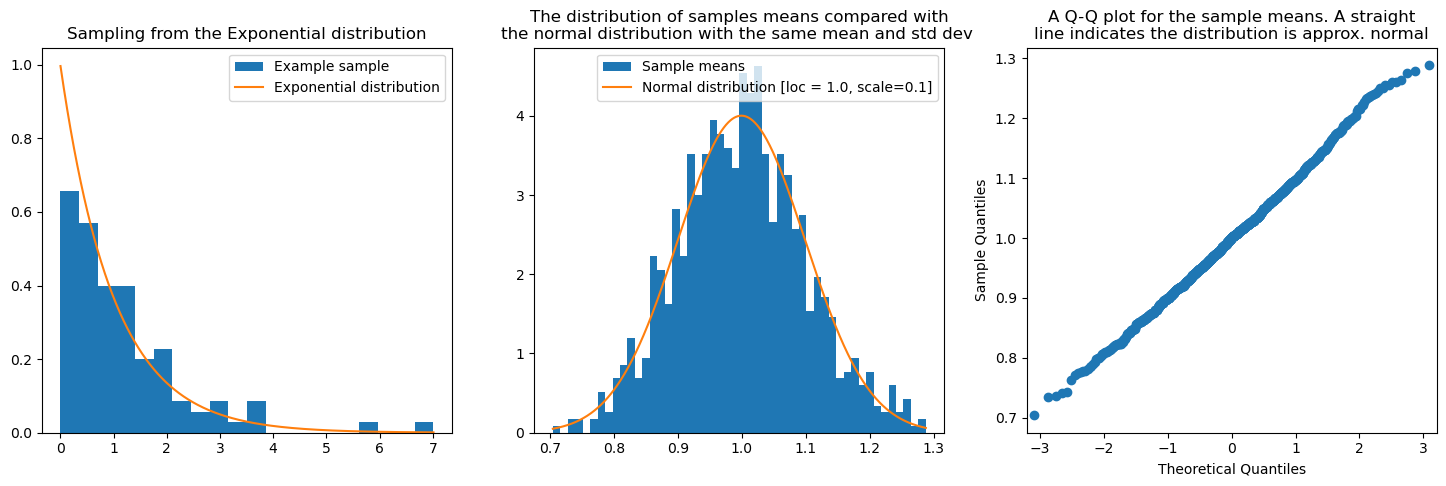

In [12]:
n_samples = 1_000
n_rows_per_sample = 100
dist = "Exponential"
loc = 0
scale = 1

dist_dict = {"Exponential": expon, "Uniform": uniform}

mean_list = []
for ii in range(n_samples):
    # draw samples from the selected distribution
    data = dist_dict[dist].rvs(loc=loc, scale=scale, size=n_rows_per_sample, random_state=ii)
    mean_list += [np.mean(data)]


# --------- Plotting
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(18, 5))

# First plot one of the data samples
ax1.hist(data, 20, density=True, label="Example sample")
X = np.linspace(min(data), max(data), 1_000)
ax1.plot(X, dist_dict[dist].pdf(X, loc=loc, scale=scale), label=f"{dist} distribution")
ax1.set_title(f"Sampling from the {dist} distribution")

# Then plot the distribution of the sample means compared with the normal distribution with the same mean and std dev 
ax2.hist(mean_list, 50, density=True, label="Sample means")
X = np.linspace(min(mean_list), max(mean_list), 1_000)
norm_mean, norm_std = np.mean(mean_list), np.std(mean_list)
ax2.plot(X, norm.pdf(X, loc=norm_mean, scale=norm_std), label=f"Normal distribution [loc = {np.round(norm_mean, 3)}, scale={np.round(norm_std, 3)}]")
ax2.set_title("The distribution of samples means compared with\nthe normal distribution with the same mean and std dev ")

# Now generate a Q-Q plot. If it returns a straight line then we can be confident that the distribution is approx. normal
sm.qqplot(np.array(mean_list), dist=norm, ax=ax3)
ax3.set_title("A Q-Q plot for the sample means. A straight\nline indicates the distribution is approx. normal")

ax1.legend()
ax2.legend()

print(f"The Shapiro-Wilk p-value: {shapiro(mean_list).pvalue}")

--------

## 6. Lack of *perfect* multicollinearity

Multicollinearity describes the situation in which two or more independent variables are linearly dependent. If we have perfect multicollinearity the regression design matrix becomes singular, which means the model has infinitely many coefficient vectors that fit the data equally well - so the OLS solution is not uniquely defined. With high multicollinearity, a unique solution exists, but the coefficient estimates become unstable. This means that small changes in the data can produce large swings in coefficients, with standard errors increasing. The reason is that it is difficult to attribute the change in the response accurately to one or another variable, since they themselves are related.

Multicollinearity is a contentious issue in statistical modelling. Some researchers suggest removing correlated variables entirely, however this seems to be an overly-simplistic approach and ignores potentially-important information. As one user in the Wikipedia forum for this issue explains, "Multicollinearity is a property of the *data* (or more accurately, the data-generating process, i.e. reality). It is not a property of the *model*. Removing collinear variables doesn't reduce the correlations between variables, it just ignores it." By removing variables from a model we risk generating a biased model which may attribute the impact of the missing variable to another variable - this relates to the above section on exogenous variables.

In general, it seems to be good practice to remove obviously-redundant variables from the very outset and, when building models for prediction, to reduce the number of highly-correlated variables if it is possible to do so without impacting significantly on model performance. Remember that in the world of statistical modelling, often it is better to have a good, stable model, than a brilliant, potentially-unstable model.

### 6.1 A model with highly correlated variables

Below we create two highly correlated variables and define their relationship with a target. We then fit a linear regression model and we see that the coefficient estimates are a long way from the true values and have a very high standard error. Note that the more correlated these two variables are, the more likely we are to see a model with coefficients that are far from the true values. We also train many models with the same features, but with slightly different error terms added to get the target. Across the iterations, we see wildly different values for the coefficients, though the spread reduces as the magnitude of the noise is reduced.

In [58]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

n_rows = 100

X1 = np.random.rand(n_rows, 1)
X2 = X1 + np.random.normal(0, 0.01, (n_rows, 1))
print("-----------\nPearson correlation coefficient", pearsonr(X1[:, 0], X2[:, 0]))

X = sm.add_constant(np.column_stack((X1, X2)))

# define the relationship between the predictors and the target
beta0, beta1, beta2 = 0, 3, 2

def fit_model(seed):
    np.random.seed(seed)
    eps = np.random.normal(0, 0.1, (n_rows, 1))
    y = beta0 + X1 * beta1 + X2 * beta2 + eps
    return sm.OLS(y, X).fit()

print("\n\n----------------\nAn example of a single model\n", fit_model(0).summary())

print("\n\n----------------\nNow we train many models, each with the same features but with slight differences in the noise added to get `y`\n")
pd.DataFrame([fit_model(ii).params for ii in range(20)], columns=["Constant", "X1_Coef", "X2_Coef"])

-----------
Pearson correlation coefficient PearsonRResult(statistic=0.9994005874998282, pvalue=5.729665529345975e-145)


----------------
An example of a single model
                             OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                     9674.
Date:                Sat, 24 Jan 2026   Prob (F-statistic):          2.24e-112
Time:                        20:14:56   Log-Likelihood:                 89.965
No. Observations:                 100   AIC:                            -173.9
Df Residuals:                      97   BIC:                            -166.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err         

,Constant,X1_Coef,X2_Coef
0,-0.024586,3.669131,1.405603
1,-0.009211,2.235829,2.801831
2,-0.037908,4.995204,0.071703
3,-0.030359,2.628668,2.419236
4,-0.000518,3.278281,1.731555
5,0.010227,4.298281,0.698703
6,-0.000124,2.539233,2.488035
7,-0.006092,4.432627,0.584839
8,0.033549,2.865785,2.067113
9,-0.048979,3.515914,1.600853


-------------

### 6.2 Variance Inflation Factor (VIF)

Note that it is possible for extreme levels of multicollinearity to exist without there being an extreme correlation between any pair of variables. This is because multicollinearity is defined as the linear dependence between two or more variables. In the example below we create three variables, where the first two are random variables and the third is the sum of the first two (plus some noise). Without adding this noise, these variables would be exactly linearly dependent and it would be possible to determine the exact value of one of them using the other two. 

In order to diagnoise high levels of multicollinearity, we can use a metric called the variance inflation factor (VIF). The minimum value for VIF is 1 whilst we get a value of infinity if perfect multicollinearity exists. The way that VIF works is that it takes one variable at a time and tries to regress all other variables onto it, i.e. it builds a regression model to predict this variable using all other variables as predictors. From this we calculate

$ VIF = \frac{1}{1-R^{2}} $

where $R^{2}$ is the coefficient of determination and is bound between 0 and 1. In the example where a third variable is the sum of the first two, we would get a VIF of infinity because a model using two variables to predict the third would be able to make perfect predictions.

In the example below we again see how multicollinearity can lead to incorrect coefficients, though note that the performance of the model is quite accurate, demonstrating that this is a problem for inference rather than prediction.

In [98]:
n_rows = 100

X1 = np.random.rand(n_rows, 1)
X2 = np.random.rand(n_rows, 1)
X3 = X1 + X2 + np.random.normal(0, 0.005, (n_rows, 1))

eps = np.random.normal(0, 0.1, (n_rows, 1))
beta0, beta1, beta2, beta3 = 0, 3, 2, 1
y = beta0 + X1 * beta1 + X2 * beta2 + X3 * beta3 + eps

X = np.column_stack((X1, X2, X3))

print("------------------\nPearson correlation coefficient")
df_corr = pd.DataFrame(X, columns=["X1", "X2", "X3"]).corr()
print(df_corr)

print("\n------------------\nVariance inflation factor")
df_vif = pd.DataFrame(
    [variance_inflation_factor(X, ii) for ii in range(X.shape[1])],
    columns=["VIF"],
    index=[f"X{ii}" for ii in range(X.shape[1])]
)
print(df_vif)


------------------
Pearson correlation coefficient
          X1        X2        X3
X1  1.000000  0.060495  0.711856
X2  0.060495  1.000000  0.744022
X3  0.711856  0.744022  1.000000

------------------
Variance inflation factor
             VIF
X0  14773.804435
X1  15113.571751
X2  52027.844394


In [99]:
# ------- Now train the model
X_sm = sm.add_constant(X)
model = sm.OLS(y, X_sm).fit()
print(model.summary())


# ------ We will also show how to calculate the coefficients from scratch
X_T = X_sm.transpose()
inverse = np.linalg.inv(np.matmul(X_T, X_sm))
coeff = np.matmul(
    np.matmul(inverse, X_T), y
)
print("\n-------------------\nCoefficients calculated from scratch")
pd.DataFrame(coeff, columns=["Coefficients"], index=["Constant"] + [f"X{ii}" for ii in range(X.shape[1])])

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                     7240.
Date:                Sat, 24 Jan 2026   Prob (F-statistic):          6.08e-113
Time:                        20:36:33   Log-Likelihood:                 87.507
No. Observations:                 100   AIC:                            -167.0
Df Residuals:                      96   BIC:                            -156.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0170      0.025     -0.676      0.5

,Coefficients
Constant,-0.017005
X0,3.547728
X1,2.546983
X2,0.476764
